# Working with Data in Python

Sam Foreman [](https://orcid.org/0000-0002-9981-0876)
(\[[ANL](https://www.anl.gov/)\](<https://alcf.anl.gov/about/people/sam-foreman>))  
2025-08-06

[](https://colab.research.google.com/github/saforem2/intro-hpc-bootcamp/blob/main/docs/00-intro-AI-HPC/4-data/index.ipynb)
[](https://github.com/saforem2/intro-hpc-bootcamp/blob/main/content/00-intro-AI-HPC/4-data/index.qmd)

> **🎯 What you’ll learn**
>
> Data is the fuel of machine learning, and three libraries do almost
> all the heavy lifting in scientific Python:
>
> - **NumPy** — fast, vectorized numerical arrays (the foundation
>   everything else builds on)
> - **pandas** — labeled, spreadsheet-like tables (`DataFrame`s) for
>   real datasets
> - **Matplotlib** — plots to actually *see* your data
>
> This page is hands-on: run each cell and tinker. It follows directly
> from [**Using Python**](../3-python/index.qmd) and sets you up for
> [**Linear Regression**](../6-linear-regression/index.qmd).

## 🔢 NumPy: arrays and vectorized math

A NumPy **array** looks like a list, but math on it happens
*element-wise* and *fast* — no Python loop:

In [1]:
import numpy as np

a = np.array([1, 2, 3, 4, 5])
print("array:      ", a)
print("times 10:   ", a * 10)        # vectorized — applies to every element
print("squared:    ", a ** 2)
print("sum / mean: ", a.sum(), a.mean())

array:       [1 2 3 4 5]
times 10:    [10 20 30 40 50]
squared:     [ 1  4  9 16 25]
sum / mean:  15 3.0

Arrays have a **shape** and can be multi-dimensional (a matrix is just a
2-D array). This is exactly how images, batches, and weight matrices are
stored:

In [2]:
M = np.arange(12).reshape(3, 4)   # 3 rows, 4 columns
print(M)
print("shape:", M.shape)
print("column means:", M.mean(axis=0))   # average down each column
print("row sums:    ", M.sum(axis=1))     # sum across each row

[[ 0  1  2  3]
 [ 4  5  6  7]
 [ 8  9 10 11]]
shape: (3, 4)
column means: [4. 5. 6. 7.]
row sums:     [ 6 22 38]

**Broadcasting** lets arrays of different shapes combine — here we
standardize each column (subtract its mean, divide by its std) in one
line:

In [3]:
col_mean = M.mean(axis=0)
col_std = M.std(axis=0)
standardized = (M - col_mean) / col_std
print(np.round(standardized, 2))

[[-1.22 -1.22 -1.22 -1.22]
 [ 0.    0.    0.    0.  ]
 [ 1.22  1.22  1.22  1.22]]

> **🎲 Reproducible randomness**
>
> Random data is everywhere in ML. Seed the generator so results are
> repeatable:
>
> ``` python
> rng = np.random.default_rng(seed=42)
> samples = rng.normal(loc=0.0, scale=1.0, size=5)
> print(np.round(samples, 3))
> ```
>
>     [ 0.305 -1.04   0.75   0.941 -1.951]

## 🐼 pandas: tables of real data

NumPy is great for pure numbers, but real datasets have **named
columns** and mixed types. That’s `pandas`. Let’s load a real dataset —
house sale prices vs. living area:

In [5]:
import pandas as pd

# download the dataset if it isn't already here (works locally and on Colab)
import os, urllib.request
url = ("https://raw.githubusercontent.com/argonne-lcf/ai-science-training-series/"
       "main/01_intro_AI_on_Supercomputer/slimmed_realestate_data.csv")
if not os.path.exists("slimmed_realestate_data.csv"):
    urllib.request.urlretrieve(url, "slimmed_realestate_data.csv")

df = pd.read_csv("slimmed_realestate_data.csv", index_col=0)
df.head()

A few things you’ll do with almost every dataset — inspect its shape,
summarize it, and select columns:

In [6]:
print("shape (rows, cols):", df.shape)
print("columns:", list(df.columns))
df.describe()

shape (rows, cols): (551, 2)
columns: ['SalePrice', 'GrLivArea']

In [7]:
# select a single column (a pandas Series) and compute on it
prices = df["SalePrice"]
print(f"cheapest:  ${prices.min():,.0f}")
print(f"priciest:  ${prices.max():,.0f}")
print(f"average:   ${prices.mean():,.0f}")

# filter rows with a boolean condition
big_expensive = df[(df["GrLivArea"] > 2000) & (df["SalePrice"] > 250_000)]
print(f"\nlarge & expensive homes: {len(big_expensive)} of {len(df)}")

cheapest:  $37,900
priciest:  $755,000
average:   $158,216

large & expensive homes: 28 of 551

## 📈 Matplotlib: seeing the data

Numbers in a table only tell you so much — plot them. A **scatter plot**
reveals the relationship between living area and price:

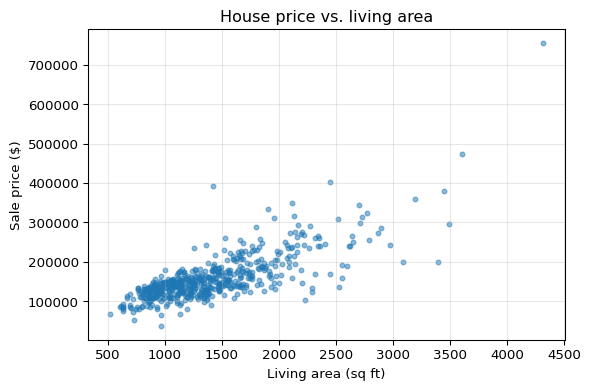

In [8]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(6.4, 4.2))
ax.scatter(df["GrLivArea"], df["SalePrice"], s=12, alpha=0.5)
ax.set_xlabel("Living area (sq ft)")
ax.set_ylabel("Sale price ($)")
ax.set_title("House price vs. living area")
ax.grid(True, alpha=0.3)
plt.show()

The upward trend is exactly what a **linear regression** model learns to
fit — which is the [next example](../6-linear-regression/index.qmd). A
**histogram** shows the *distribution* of a single variable:

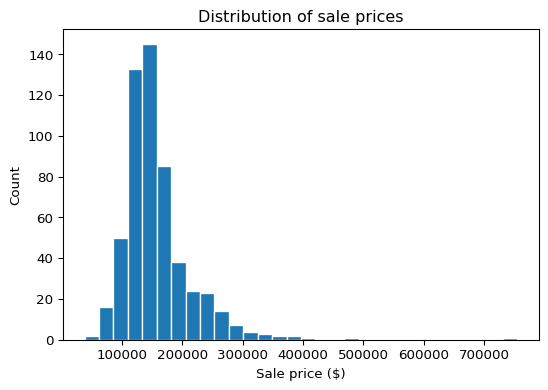

In [9]:
fig, ax = plt.subplots(figsize=(6.4, 4.2))
ax.hist(df["SalePrice"], bins=30, edgecolor="white")
ax.set_xlabel("Sale price ($)")
ax.set_ylabel("Count")
ax.set_title("Distribution of sale prices")
plt.show()

## Exercises

Attempt each before revealing the solution.

> **Exercise 1 — NumPy**
>
> Create a NumPy array of the integers 1 through 10, then print the mean
> of only the **even** numbers. (Hint: boolean indexing,
> `a[a % 2 == 0]`.)
>
> > **💡 Solution**
> >
> > ``` python
> > a = np.arange(1, 11)
> > print(a[a % 2 == 0].mean())   # (2+4+6+8+10)/5 = 6.0
> > ```
> >
> >     6.0

> **Exercise 2 — pandas**
>
> Add a new column `PricePerSqFt` to `df` equal to
> `SalePrice / GrLivArea`, then print its average.
>
> > **💡 Solution**
> >
> > ``` python
> > df["PricePerSqFt"] = df["SalePrice"] / df["GrLivArea"]
> > print(f"avg price/sqft: ${df['PricePerSqFt'].mean():,.2f}")
> > ```
> >
> >     avg price/sqft: $116.13

> **Exercise 3 — plotting**
>
> Make a histogram of `GrLivArea` with 20 bins. What’s the most common
> range of house sizes?
>
> > **💡 Solution**
> >
> > ``` python
> > fig, ax = plt.subplots(figsize=(6.4, 4.2))
> > ax.hist(df["GrLivArea"], bins=20, edgecolor="white")
> > ax.set_xlabel("Living area (sq ft)"); ax.set_ylabel("Count")
> > plt.show()
> > ```
> >
> > 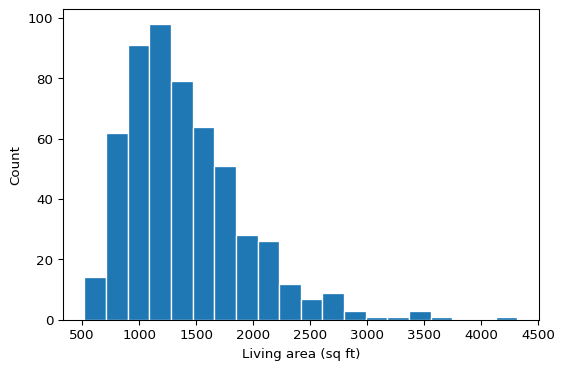

## 🔑 Key takeaways

- **NumPy** arrays do fast, vectorized, element-wise math (`a * 10`,
  `M.mean(axis=0)`).
- **Broadcasting** combines arrays of different shapes without loops.
- **pandas** `DataFrame`s hold labeled tables — `read_csv`, `.head()`,
  `.describe()`, column selection, boolean filtering.
- **Matplotlib** turns arrays/columns into scatter plots and histograms.

> **📓 Go deeper**
>
> - [NumPy: the absolute basics for
>   beginners](https://numpy.org/doc/stable/user/absolute_beginners.html)
> - [pandas: 10 minutes to
>   pandas](https://pandas.pydata.org/docs/user_guide/10min.html)
> - [Python Data Science
>   Handbook](https://jakevdp.github.io/PythonDataScienceHandbook/index.html)
> - [MachineLearningStatistics · Visualization
>   notebook](https://github.com/dkirkby/MachineLearningStatistics/blob/3aa7385e1fd0b1572013bdf1f1c823806b744b2d/notebooks/Visualization.ipynb)

➡️ **Next:** [Linear Regression](../6-linear-regression/index.qmd) —
train your first model on exactly this dataset.